In [5]:
import pickle
import statistics

In [6]:
from glob import glob
tif_list = glob('/data1/r20user3/shared_project/Hist2Cell/code/training/train_test_splits/humanlung_cell2location/test*')
tif_list.sort()
test_slides = list()
for tif in tif_list:
    tif_path = tif.split('_')[-1].split('.')[0]
    test_slides.append(tif_path)
test_slides

['A37', 'A42', 'A48', 'A50']

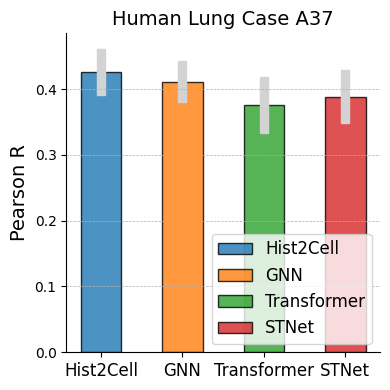

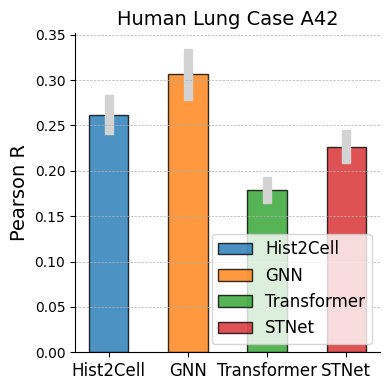

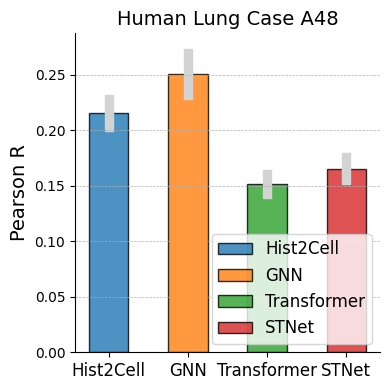

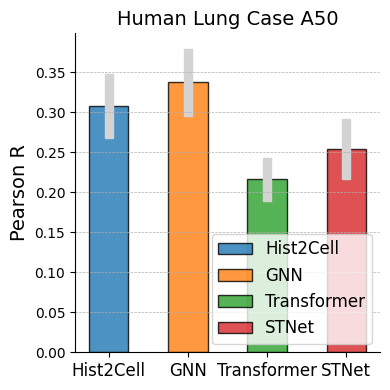

In [3]:
# ensemble_mean_overall = []
# ensemble_std_overall = []
# gcn_mean_overall = []
# gcn_std_overall = []
# trans_mean_overall = []
# trans_std_overall = []
# densenet_mean_overall = []
# densenet_std_overall = []

for case in test_slides:

    with open('/data1/r20user3/shared_project/Hist2Cell/code/training/pearson_log/humanlung_epoch100_lr1e-4_2hop_ensemble_onlycell_'+case+'_cell_pearson_list.pkl', 'rb') as f:
        multi_cell_pearson_list = pickle.load(f)
    ensemble_mean = statistics.mean(multi_cell_pearson_list)
    ensemble_std = statistics.variance(multi_cell_pearson_list)

    with open('/data1/r20user3/shared_project/Hist2Cell/code/training/pearson_log/humanlung_epoch100_lr1e-4_2hop_rawimgGNN_onlycell_'+case+'_cell_pearson_list.pkl', 'rb') as f:
        multi_cell_pearson_list = pickle.load(f)
    gcn_mean = statistics.mean(multi_cell_pearson_list)
    gcn_std = statistics.variance(multi_cell_pearson_list)

    with open('/data1/r20user3/shared_project/Hist2Cell/code/training/pearson_log/humanlung_epoch100_lr1e-4_2hop_rawimgTrans1layer_onlycell_'+case+'_cell_pearson_list.pkl', 'rb') as f:
        multi_cell_pearson_list = pickle.load(f)
    trans_mean = statistics.mean(multi_cell_pearson_list)
    trans_std = statistics.variance(multi_cell_pearson_list)

    with open('/data1/r20user3/shared_project/Hist2Cell/code/training/pearson_log/humanlung_epoch100_lr1e-4_densenet_onlycell_'+case+'_cell_pearson_list.pkl', 'rb') as f:
        multi_cell_pearson_list = pickle.load(f)
    densenet_mean = statistics.mean(multi_cell_pearson_list)
    densenet_std = statistics.variance(multi_cell_pearson_list)
    
    import numpy as np
    import matplotlib.pyplot as plt

    models = ['Hist2Cell', 'GNN', 'Transformer', 'STNet']
    accuracy = [ensemble_mean, gcn_mean, trans_mean, densenet_mean]
    std_dev = [ensemble_std, gcn_std, trans_std, densenet_std]
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

    # Function to draw solid error bars
    def draw_solid_error_bars(ax, x, y, errors, width=0.1, color='black'):
        for i in range(len(x)):
            rect = plt.Rectangle((x[i] - width / 2, y[i] - errors[i]), width, errors[i] * 2, color=color)
            ax.add_patch(rect)

    # Create a single subplot
    fig, ax = plt.subplots(figsize=(4, 4))

    # Set the width of each bar
    bar_width = 0.5

    # Set the x position of each model's bar
    x_pos = np.arange(len(models))

    # Draw the bar plot with different colors and solid error bars
    for i in range(len(models)):
        bar_plot = ax.bar(x_pos[i], accuracy[i], width=bar_width, align='center', alpha=0.8, color=colors[i], label=models[i], edgecolor='black')
        draw_solid_error_bars(ax, [x_pos[i]], [accuracy[i]], [std_dev[i]], width=0.1, color='lightgray')

    # Set labels, legend, and title
    ax.set_xticks(x_pos)
    ax.set_xticklabels(models, fontsize=12)
    ax.set_ylabel('Pearson R', fontsize=14)
    ax.legend(fontsize=12, loc='lower right')
    ax.set_title('Human Lung Case '+case, fontsize=14)

    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Add gridlines
    ax.yaxis.grid(True, linestyle='--', linewidth=0.5)

    # Save the figure and show
    plt.tight_layout()
    # plt.savefig('/home/r15user3/Documents/shared_project/Hist2Cell/code/analysis/pearson_analysis/pearson_bar_with_std_each_case_humanlung/'+case+'.png', dpi=300)
    plt.show()

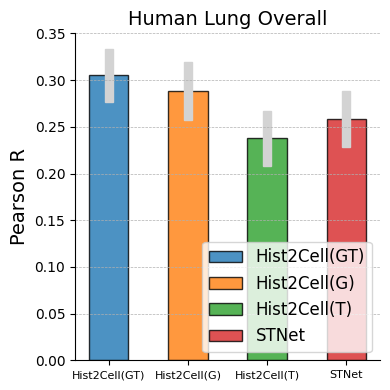

[0.30501123 0.28822367 0.23801578 0.25847764]


In [15]:
import numpy as np
import matplotlib.pyplot as plt

accuracy_means = []
accuracy_std_devs = []

# Loop through all cases
for case in test_slides:
    with open('/data1/r20user3/shared_project/Hist2Cell/code/training/pearson_log/humanlung_epoch100_lr1e-4_2hop_ensemble_Trans1layer_onlycell_'+case+'_cell_pearson_list.pkl', 'rb') as f:
        multi_cell_pearson_list = pickle.load(f)
    ensemble_mean = statistics.mean(multi_cell_pearson_list)
    ensemble_std = statistics.variance(multi_cell_pearson_list)

    with open('/data1/r20user3/shared_project/Hist2Cell/code/training/pearson_log/humanlung_epoch100_lr1e-4_2hop_ensemble_addrelu_onlycell_'+case+'_cell_pearson_list.pkl', 'rb') as f:
        multi_cell_pearson_list = pickle.load(f)
    gcn_mean = statistics.mean(multi_cell_pearson_list)
    gcn_std = statistics.variance(multi_cell_pearson_list)

    with open('/data1/r20user3/shared_project/Hist2Cell/code/training/pearson_log/humanlung_epoch100_lr1e-4_2hop_rawimgTrans_onlycell_'+case+'_cell_pearson_list.pkl', 'rb') as f:
        multi_cell_pearson_list = pickle.load(f)
    trans_mean = statistics.mean(multi_cell_pearson_list)
    trans_std = statistics.variance(multi_cell_pearson_list)

    with open('/data1/r20user3/shared_project/Hist2Cell/code/training/pearson_log/humanlung_epoch100_lr1e-4_densenet_onlycell_'+case+'_cell_pearson_list.pkl', 'rb') as f:
        multi_cell_pearson_list = pickle.load(f)
    densenet_mean = statistics.mean(multi_cell_pearson_list)
    densenet_std = statistics.variance(multi_cell_pearson_list)

    # Append the mean and standard deviation to the lists
    accuracy_means.append([ensemble_mean, gcn_mean, trans_mean, densenet_mean])
    accuracy_std_devs.append([ensemble_std, gcn_std, trans_std, densenet_std])

# Calculate the overall mean and standard deviation across all cases
overall_mean = np.mean(accuracy_means, axis=0)
overall_std = np.sqrt(np.sum(np.power(accuracy_std_devs, 2), axis=0) / len(test_slides))

models = ['Hist2Cell(GT)', 'Hist2Cell(G)', 'Hist2Cell(T)', 'STNet']
accuracy = overall_mean
std_dev = overall_std
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# Function to draw solid error bars
def draw_solid_error_bars(ax, x, y, errors, width=0.1, color='black'):
    for i in range(len(x)):
        rect = plt.Rectangle((x[i] - width / 2, y[i] - errors[i]), width, errors[i] * 2, color=color)
        ax.add_patch(rect)

# Create a single subplot
fig, ax = plt.subplots(figsize=(4, 4))

# Set the width of each bar
bar_width = 0.5

# Set the x position of each model's bar
x_pos = np.arange(len(models))

# Draw the bar plot with different colors and solid error bars
for i in range(len(models)):
    bar_plot = ax.bar(x_pos[i], accuracy[i], width=bar_width, align='center', alpha=0.8, color=colors[i], label=models[i], edgecolor='black')
    draw_solid_error_bars(ax, [x_pos[i]], [accuracy[i]], [std_dev[i]], width=0.1, color='lightgray')

# Set labels, legend, and title
ax.set_xticks(x_pos)
ax.set_xticklabels(models, fontsize=8)
ax.set_ylabel('Pearson R', fontsize=14)
ax.legend(fontsize=12, loc='lower right')
ax.set_title('Human Lung Overall', fontsize=14)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add gridlines
ax.yaxis.grid(True, linestyle='--', linewidth=0.5)

# Save the figure and show
plt.tight_layout()
# plt.savefig('/home/r15user3/Documents/shared_project/Hist2Cell/code/analysis/pearson_analysis/pearson_bar_with_std_each_case_humanlung/'+'overall'+'.png', dpi=300)
plt.show()
print(overall_mean)

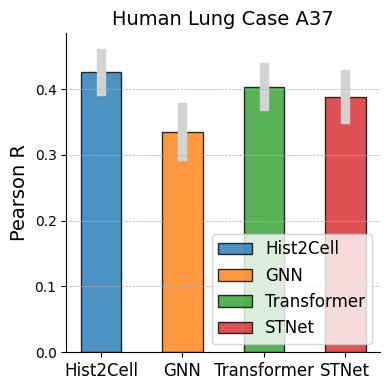

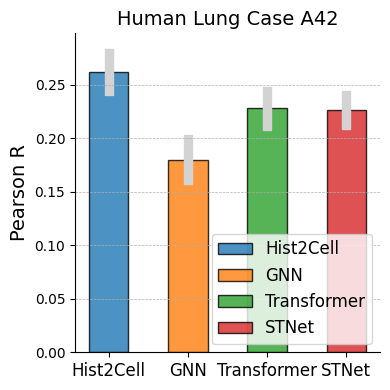

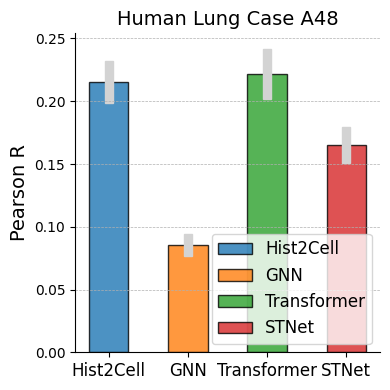

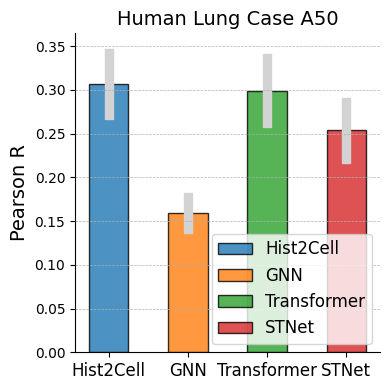

In [5]:
for case in test_slides:

    with open('/data1/r20user3/shared_project/Hist2Cell/code/training/pearson_log/humanlung_epoch100_lr1e-4_2hop_ensemble_onlycell_'+case+'_cell_pearson_list.pkl', 'rb') as f:
        multi_cell_pearson_list = pickle.load(f)
    ensemble_mean = statistics.mean(multi_cell_pearson_list)
    ensemble_std = statistics.variance(multi_cell_pearson_list)

    with open('/data1/r20user3/shared_project/Hist2Cell/code/training/pearson_log/humanlung_epoch2000_lr1e-4_GCN_onlycell_'+case+'_cell_pearson_list.pkl', 'rb') as f:
        multi_cell_pearson_list = pickle.load(f)
    gcn_mean = statistics.mean(multi_cell_pearson_list)
    gcn_std = statistics.variance(multi_cell_pearson_list)

    with open('/data1/r20user3/shared_project/Hist2Cell/code/training/pearson_log/humanlung_epoch100_lr1e-4_2hop_ensemble_addrelu_onlycell_'+case+'_cell_pearson_list.pkl', 'rb') as f:
        multi_cell_pearson_list = pickle.load(f)
    trans_mean = statistics.mean(multi_cell_pearson_list)
    trans_std = statistics.variance(multi_cell_pearson_list)

    with open('/data1/r20user3/shared_project/Hist2Cell/code/training/pearson_log/humanlung_epoch100_lr1e-4_densenet_onlycell_'+case+'_cell_pearson_list.pkl', 'rb') as f:
        multi_cell_pearson_list = pickle.load(f)
    densenet_mean = statistics.mean(multi_cell_pearson_list)
    densenet_std = statistics.variance(multi_cell_pearson_list)
    
    import numpy as np
    import matplotlib.pyplot as plt

    models = ['Hist2Cell', 'GNN', 'Transformer', 'STNet']
    accuracy = [ensemble_mean, gcn_mean, trans_mean, densenet_mean]
    std_dev = [ensemble_std, gcn_std, trans_std, densenet_std]
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

    # Function to draw solid error bars
    def draw_solid_error_bars(ax, x, y, errors, width=0.1, color='black'):
        for i in range(len(x)):
            rect = plt.Rectangle((x[i] - width / 2, y[i] - errors[i]), width, errors[i] * 2, color=color)
            ax.add_patch(rect)

    # Create a single subplot
    fig, ax = plt.subplots(figsize=(4, 4))

    # Set the width of each bar
    bar_width = 0.5

    # Set the x position of each model's bar
    x_pos = np.arange(len(models))

    # Draw the bar plot with different colors and solid error bars
    for i in range(len(models)):
        bar_plot = ax.bar(x_pos[i], accuracy[i], width=bar_width, align='center', alpha=0.8, color=colors[i], label=models[i], edgecolor='black')
        draw_solid_error_bars(ax, [x_pos[i]], [accuracy[i]], [std_dev[i]], width=0.1, color='lightgray')

    # Set labels, legend, and title
    ax.set_xticks(x_pos)
    ax.set_xticklabels(models, fontsize=12)
    ax.set_ylabel('Pearson R', fontsize=14)
    ax.legend(fontsize=12, loc='lower right')
    ax.set_title('Human Lung Case '+case, fontsize=14)

    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Add gridlines
    ax.yaxis.grid(True, linestyle='--', linewidth=0.5)

    # Save the figure and show
    plt.tight_layout()
    # plt.savefig('/home/r15user3/Documents/shared_project/Hist2Cell/code/analysis/pearson_analysis/pearson_bar_with_std_each_case_humanlung/'+case+'.png', dpi=300)
    plt.show()

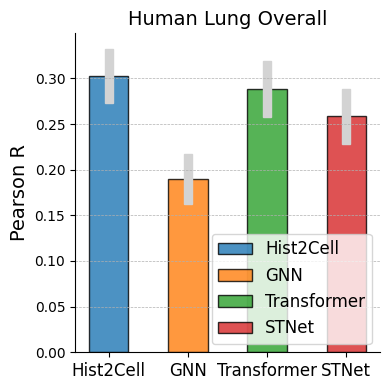

In [7]:
accuracy_means = []
accuracy_std_devs = []

# Loop through all cases
for case in test_slides:
    with open('/data1/r20user3/shared_project/Hist2Cell/code/training/pearson_log/humanlung_epoch100_lr1e-4_2hop_ensemble_onlycell_'+case+'_cell_pearson_list.pkl', 'rb') as f:
        multi_cell_pearson_list = pickle.load(f)
    ensemble_mean = statistics.mean(multi_cell_pearson_list)
    ensemble_std = statistics.variance(multi_cell_pearson_list)

    with open('/data1/r20user3/shared_project/Hist2Cell/code/training/pearson_log/humanlung_epoch2000_lr1e-4_GCN_onlycell_'+case+'_cell_pearson_list.pkl', 'rb') as f:
        multi_cell_pearson_list = pickle.load(f)
    gcn_mean = statistics.mean(multi_cell_pearson_list)
    gcn_std = statistics.variance(multi_cell_pearson_list)

    with open('/data1/r20user3/shared_project/Hist2Cell/code/training/pearson_log/humanlung_epoch100_lr1e-4_2hop_ensemble_addrelu_onlycell_'+case+'_cell_pearson_list.pkl', 'rb') as f:
        multi_cell_pearson_list = pickle.load(f)
    trans_mean = statistics.mean(multi_cell_pearson_list)
    trans_std = statistics.variance(multi_cell_pearson_list)

    with open('/data1/r20user3/shared_project/Hist2Cell/code/training/pearson_log/humanlung_epoch100_lr1e-4_densenet_onlycell_'+case+'_cell_pearson_list.pkl', 'rb') as f:
        multi_cell_pearson_list = pickle.load(f)
    densenet_mean = statistics.mean(multi_cell_pearson_list)
    densenet_std = statistics.variance(multi_cell_pearson_list)

    # Append the mean and standard deviation to the lists
    accuracy_means.append([ensemble_mean, gcn_mean, trans_mean, densenet_mean])
    accuracy_std_devs.append([ensemble_std, gcn_std, trans_std, densenet_std])

# Calculate the overall mean and standard deviation across all cases
overall_mean = np.mean(accuracy_means, axis=0)
overall_std = np.sqrt(np.sum(np.power(accuracy_std_devs, 2), axis=0) / len(test_slides))

models = ['Hist2Cell', 'GNN', 'Transformer', 'STNet']
accuracy = overall_mean
std_dev = overall_std
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# Function to draw solid error bars
def draw_solid_error_bars(ax, x, y, errors, width=0.1, color='black'):
    for i in range(len(x)):
        rect = plt.Rectangle((x[i] - width / 2, y[i] - errors[i]), width, errors[i] * 2, color=color)
        ax.add_patch(rect)

# Create a single subplot
fig, ax = plt.subplots(figsize=(4, 4))

# Set the width of each bar
bar_width = 0.5

# Set the x position of each model's bar
x_pos = np.arange(len(models))

# Draw the bar plot with different colors and solid error bars
for i in range(len(models)):
    bar_plot = ax.bar(x_pos[i], accuracy[i], width=bar_width, align='center', alpha=0.8, color=colors[i], label=models[i], edgecolor='black')
    draw_solid_error_bars(ax, [x_pos[i]], [accuracy[i]], [std_dev[i]], width=0.1, color='lightgray')

# Set labels, legend, and title
ax.set_xticks(x_pos)
ax.set_xticklabels(models, fontsize=12)
ax.set_ylabel('Pearson R', fontsize=14)
ax.legend(fontsize=12, loc='lower right')
ax.set_title('Human Lung Overall', fontsize=14)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add gridlines
ax.yaxis.grid(True, linestyle='--', linewidth=0.5)

# Save the figure and show
plt.tight_layout()
# plt.savefig('/home/r15user3/Documents/shared_project/Hist2Cell/code/analysis/pearson_analysis/pearson_bar_with_std_each_case_humanlung/'+'overall'+'.png', dpi=300)
plt.show()